In [11]:
# ============================================================
# NHL PREDICTION MODEL - SKELLAM / DIXON-COLES VERSION
# ============================================================
# Replaces Bradley-Terry win/loss model with:
#   - Poisson attack/defense ratings fit via MLE
#   - Dixon-Coles low-score correction
#   - Skellam distribution for win/draw/loss probabilities
#   - Same blending framework (prior → current season)
#   - Same goalie GSAx adjustment logic

import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.stats import skellam
from scipy.special import factorial
from sqlalchemy import create_engine
from datetime import datetime
import json
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("NHL Prediction Model - Skellam/Dixon-Coles Version")
print(f"Date: {datetime.now().strftime('%B %d, %Y')}\n")

NHL Prediction Model - Skellam/Dixon-Coles Version
Date: March 21, 2026



In [12]:
# ============================================================
# PART 1: DATABASE CONNECTION & DATA LOADING
# ============================================================

DB_HOST = "db.wluxnhuyfumkannjvgiu.supabase.co"
DB_PORT = "5432"
DB_NAME = "postgres"
DB_USER = "postgres"
DB_PASS = "BlueISland$$87"

connection_string = (
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    f"?sslmode=require"
)
engine = create_engine(connection_string)
print("✅ Connected to Supabase\n")

✅ Connected to Supabase



In [13]:
# Load game data
query_games = """
    SELECT 
        "gameId", season, team, "opposingTeam",
        "goalsFor", "goalsAgainst", home_or_away, "gameDate",
        "xGoalsFor", "xGoalsAgainst", "corsiPercentage",
        "shotsOnGoalFor", "shotsOnGoalAgainst",
        "scoreAdjustedShotsAttemptsFor", "scoreAdjustedShotsAttemptsAgainst",
        "highDangerxGoalsFor", "highDangerxGoalsAgainst"
    FROM "NHL_Gamelog"
    WHERE situation = 'all'
    AND position = 'Team Level'
    AND "playoffGame" = '0'
    AND season IN (2024, 2025)
"""
games_df = pd.read_sql(query_games, engine)

# Cast numeric columns (Supabase returns them as strings)
numeric_cols = [
    'goalsFor', 'goalsAgainst', 'xGoalsFor', 'xGoalsAgainst',
    'corsiPercentage', 'shotsOnGoalFor', 'shotsOnGoalAgainst',
    'scoreAdjustedShotsAttemptsFor', 'scoreAdjustedShotsAttemptsAgainst',
    'highDangerxGoalsFor', 'highDangerxGoalsAgainst', 'season'
]
for col in numeric_cols:
    games_df[col] = pd.to_numeric(games_df[col], errors='coerce')

prior_season   = games_df[games_df['season'] == 2024].copy()
current_season = games_df[games_df['season'] == 2025].copy()

print(f"Prior season   (2024-25): {len(prior_season['gameId'].unique())} games")
print(f"Current season (2025-26): {len(current_season['gameId'].unique())} games\n")

Prior season   (2024-25): 1312 games
Current season (2025-26): 1082 games



In [14]:
# Load goalie data
query_goalies = """
    SELECT name, team, season, situation, games_played, "xGoals", goals
    FROM "Goalie_stats"
    WHERE season = 2025
"""
goalie_df = pd.read_sql(query_goalies, engine)

# Cast numeric columns
for col in ['games_played', 'xGoals', 'goals']:
    goalie_df[col] = pd.to_numeric(goalie_df[col], errors='coerce')

print(f"Loaded {len(goalie_df[goalie_df['situation']=='all'])} goalies\n")

Loaded 94 goalies



In [15]:
# ============================================================
# PART 2: DIXON-COLES POISSON MODEL
# ============================================================

def dc_rho(goals_h, goals_a, lam_h, lam_a, rho):
    """
    Dixon-Coles correction factor for low-scoring games.
    Adjusts the independent Poisson assumption for scorelines
    {0-0, 1-0, 0-1, 1-1} which are empirically over/under-represented.
    """
    if goals_h == 0 and goals_a == 0:
        return 1 - lam_h * lam_a * rho
    elif goals_h == 1 and goals_a == 0:
        return 1 + lam_a * rho
    elif goals_h == 0 and goals_a == 1:
        return 1 + lam_h * rho
    elif goals_h == 1 and goals_a == 1:
        return 1 - rho
    else:
        return 1.0


def poisson_pmf(k, lam):
    """Safe Poisson PMF."""
    return np.exp(-lam) * (lam ** k) / factorial(k)


class DixonColesModel:
    """
    Dixon-Coles Poisson model for goal prediction.

    Each team has:
      - attack  (log-scale offensive strength)
      - defense (log-scale defensive weakness — higher = worse)

    Expected goals:
      lam_home = exp(log_mu + home_adv + home_attack - away_defense)
      lam_away = exp(log_mu            + away_attack - home_defense)

    Fit via MLE with Dixon-Coles correction on low-scoring outcomes.
    Supports exponential time-weighting so recent games count more.
    """

    def __init__(self):
        self.attack   = {}
        self.defense  = {}
        self.home_adv = None
        self.log_mu   = None
        self.rho      = None
        self.teams    = []

    def _deduplicate(self, games_df):
        """Return one row per game from the home team perspective."""
        home = games_df[games_df['home_or_away'] == 'HOME'].copy()
        if len(home) == 0:
            seen, rows = set(), []
            for _, r in games_df.iterrows():
                if r['gameId'] not in seen:
                    seen.add(r['gameId'])
                    rows.append(r)
            home = pd.DataFrame(rows)
        return home

    def fit(self, games_df, xi=0.005, reference_date=None):
        """
        Fit attack/defense ratings via time-weighted MLE.

        Parameters
        ----------
        xi             : float  Exponential decay rate per day.
                                0.0 = no decay (uniform weights).
                                0.005 = ~half-weight after ~139 days.
        reference_date : date   Date to measure decay from.
                                Defaults to the most recent game in games_df.
        """
        self.teams = sorted(games_df['team'].unique().tolist())
        n    = len(self.teams)
        t2i  = {t: i for i, t in enumerate(self.teams)}
        home_games = self._deduplicate(games_df).reset_index(drop=True)

        # ── Time weights ──────────────────────────────────────
        if xi > 0:
            dates = pd.to_datetime(home_games['gameDate'])
            if reference_date is None:
                ref = dates.max()
            else:
                ref = pd.to_datetime(reference_date)
            days_ago = (ref - dates).dt.days.clip(lower=0).values
            weights  = np.exp(-xi * days_ago)
        else:
            weights = np.ones(len(home_games))

        # Parameters: [log_mu, home_adv, rho, attack[1..n-1], defense[0..n-1]]
        # attack[0] pinned to 0 for identifiability
        n_params = 3 + (n - 1) + n

        def params_to_dict(p):
            log_mu   = p[0]
            home_adv = p[1]
            rho      = np.clip(p[2], -0.99, 0.99)
            attack   = np.concatenate([[0.0], p[3:3 + n - 1]])
            defense  = p[3 + n - 1:]
            return log_mu, home_adv, rho, attack, defense

        def neg_log_likelihood(p):
            log_mu, home_adv, rho, attack, defense = params_to_dict(p)
            ll = 0.0
            for idx, row in home_games.iterrows():
                hi = t2i.get(row['team'])
                ai = t2i.get(row['opposingTeam'])
                if hi is None or ai is None:
                    continue
                gh    = int(row['goalsFor'])
                ga    = int(row['goalsAgainst'])
                lam_h = np.clip(np.exp(log_mu + home_adv + attack[hi] - defense[ai]), 0.01, 20)
                lam_a = np.clip(np.exp(log_mu             + attack[ai] - defense[hi]), 0.01, 20)
                dc    = max(dc_rho(gh, ga, lam_h, lam_a, rho), 1e-10)
                game_ll = (np.log(poisson_pmf(gh, lam_h) + 1e-10)
                         + np.log(poisson_pmf(ga, lam_a) + 1e-10)
                         + np.log(dc))
                ll += weights[idx] * game_ll
            return -ll

        avg_goals = home_games['goalsFor'].mean()
        x0        = np.zeros(n_params)
        x0[0]     = np.log(max(avg_goals, 0.5))
        x0[1]     = 0.1
        x0[2]     = -0.1

        result = minimize(neg_log_likelihood, x0, method='L-BFGS-B',
                          options={'maxiter': 300, 'ftol': 1e-7})

        log_mu, home_adv, rho, attack_arr, defense_arr = params_to_dict(result.x)
        self.log_mu   = log_mu
        self.home_adv = home_adv
        self.rho      = np.clip(rho, -0.99, 0.99)
        self.attack   = {t: attack_arr[i]  for i, t in enumerate(self.teams)}
        self.defense  = {t: defense_arr[i] for i, t in enumerate(self.teams)}
        return self

In [16]:
# ============================================================
# PART 3: SKELLAM PROBABILITY ENGINE
# ============================================================

def skellam_probabilities(lam_h, lam_a, rho=-0.1, max_goals=15, ou_line=None):
    """
    Compute win/draw/loss, puck line, and totals probabilities from
    the full Dixon-Coles score matrix.

    Parameters
    ----------
    lam_h     : float  Expected home goals
    lam_a     : float  Expected away goals
    rho       : float  Dixon-Coles correction parameter
    max_goals : int    Max goals per team to consider
    ou_line   : float  O/U line (e.g. 5.5, 6.0). If None, totals
                       probs are not computed.
    """
    score_matrix = np.zeros((max_goals + 1, max_goals + 1))
    for gh in range(max_goals + 1):
        for ga in range(max_goals + 1):
            dc   = dc_rho(gh, ga, lam_h, lam_a, rho)
            prob = poisson_pmf(gh, lam_h) * poisson_pmf(ga, lam_a) * dc
            score_matrix[gh, ga] = max(prob, 0)

    total = score_matrix.sum()
    if total > 0:
        score_matrix /= total

    # ── Moneyline ─────────────────────────────────────────
    home_win = np.tril(score_matrix, -1).sum()   # gh > ga
    draw     = np.trace(score_matrix)            # gh == ga (goes to OT)
    away_win = np.triu(score_matrix,  1).sum()   # ga > gh

    home_total = home_win + draw * 0.50
    away_total = away_win + draw * 0.50

    # ── Puck line (±1.5) ──────────────────────────────────
    # home -1.5: home wins by 2+  →  gh - ga >= 2
    # away +1.5: home wins by <=1 →  gh - ga <= 1
    home_pl_prob = 0.0
    away_pl_prob = 0.0
    for gh in range(max_goals + 1):
        for ga in range(max_goals + 1):
            diff = gh - ga
            if diff >= 2:
                home_pl_prob += score_matrix[gh, ga]
            else:
                away_pl_prob += score_matrix[gh, ga]

    # ── Totals ────────────────────────────────────────────
    over_prob = under_prob = push_prob = None
    if ou_line is not None:
        over_prob  = 0.0
        under_prob = 0.0
        push_prob  = 0.0
        for gh in range(max_goals + 1):
            for ga in range(max_goals + 1):
                t = gh + ga
                if   t > ou_line: over_prob  += score_matrix[gh, ga]
                elif t < ou_line: under_prob += score_matrix[gh, ga]
                else:             push_prob  += score_matrix[gh, ga]
        # Redistribute push to over/under (book refunds push → fair prob)
        denom = over_prob + under_prob
        over_fair  = over_prob  / denom if denom > 0 else None
        under_fair = under_prob / denom if denom > 0 else None
    else:
        over_fair = under_fair = None

    result = {
        # Moneyline
        'home_win_prob':     round(home_total,       4),
        'away_win_prob':     round(away_total,       4),
        'home_reg_prob':     round(home_win,         4),
        'away_reg_prob':     round(away_win,         4),
        'ot_prob':           round(draw,             4),
        # Puck line
        'home_pl_prob':      round(home_pl_prob,     4),
        'away_pl_prob':      round(away_pl_prob,     4),
        # Expected goals
        'lam_home':          round(lam_h,            3),
        'lam_away':          round(lam_a,            3),
        'expected_total':    round(lam_h + lam_a,    3),
        # Implied odds
        'home_implied_odds': round(1 / home_total,   3) if home_total > 0 else 999,
        'away_implied_odds': round(1 / away_total,   3) if away_total > 0 else 999,
    }

    if ou_line is not None:
        result['over_prob']   = round(over_prob,  4)
        result['under_prob']  = round(under_prob, 4)
        result['push_prob']   = round(push_prob,  4)
        result['over_fair']   = round(over_fair,  4) if over_fair  is not None else None
        result['under_fair']  = round(under_fair, 4) if under_fair is not None else None

    return result

In [17]:
# ============================================================
# PART 4: CURRENT SEASON METRICS
# ============================================================

class CurrentSeasonMetrics:
    """
    Compute metric-based attack/defense adjustments from xG, Corsi, HDCF.
    Returns log-scale additive adjustments compatible with Dixon-Coles.
    """

    def __init__(self, df):
        self.atk_adj = {}
        self.def_adj = {}
        if len(df) > 0:
            self._calculate(df)

    def _calculate(self, df):
        records = []
        for team in df['team'].unique():
            tg = df[df['team'] == team]
            n  = len(tg)
            records.append({
                'team':      team,
                'xgf_pg':   tg['xGoalsFor'].sum() / n,
                'xga_pg':   tg['xGoalsAgainst'].sum() / n,
                'hdxgf_pg': tg['highDangerxGoalsFor'].sum() / n,
                'hdxga_pg': tg['highDangerxGoalsAgainst'].sum() / n,
                'sogf_pg':  tg['shotsOnGoalFor'].sum() / n,
                'soga_pg':  tg['shotsOnGoalAgainst'].sum() / n,
            })
        mdf = pd.DataFrame(records)

        def zscore(col):
            s = mdf[col].std()
            return (mdf[col] - mdf[col].mean()) / s if s > 0 else 0

        # Attack signal: xGF, HD xGF, SOG For
        atk_z = 0.50 * zscore('xgf_pg') + 0.30 * zscore('hdxgf_pg') + 0.20 * zscore('sogf_pg')
        # Defense signal: xGA, HD xGA, SOG Against (lower = better)
        def_z = 0.50 * zscore('xga_pg') + 0.30 * zscore('hdxga_pg') + 0.20 * zscore('soga_pg')

        # Scale z-scores to log-space adjustments (~±0.10 log-units per 1σ)
        scale = 0.10
        for i, row in mdf.iterrows():
            team = row['team']
            self.atk_adj[team] = float(atk_z.iloc[i] * scale)
            self.def_adj[team] = float(def_z.iloc[i] * scale)

    def get_atk(self, team): return self.atk_adj.get(team, 0.0)
    def get_def(self, team): return self.def_adj.get(team, 0.0)

In [18]:
# ============================================================
# PART 5: GOALIE RATINGS (GSAx → log-space defense adjustment)
# ============================================================

class GoalieRatings:
    """
    Load goalie GSAx and convert to log-space defense adjustments.
    A great goalie reduces opponent effective attack in log-space.

    Elite (+0.30 GSAx/GP) → +0.099 log adjustment
    Bad   (-0.30 GSAx/GP) → -0.099 log adjustment
    """

    def __init__(self, goalie_df):
        self.ratings = {}
        self._load(goalie_df)

    def _load(self, df):
        gdf = df[(df['situation'] == 'all') & (df['games_played'] >= 5)].copy()
        gdf['gsax']       = gdf['xGoals'] - gdf['goals']
        gdf['gsax_per_gp'] = gdf['gsax'] / gdf['games_played']
        for _, row in gdf.iterrows():
            gsax_pg = np.clip(row['gsax_per_gp'], -0.40, 0.40)
            self.ratings[row['name']] = {
                'log_adj': gsax_pg * 0.33,
                'gsax':    row['gsax'],
                'gsax_pg': row['gsax_per_gp'],
                'games':   row['games_played'],
                'team':    row['team'],
            }

    def get_log_adj(self, name):
        """Positive = goalie saves more than expected = opponent scores less."""
        return self.ratings[name]['log_adj'] if name in self.ratings else 0.0

    def info(self, name):
        return self.ratings.get(name, {})

In [19]:
# ============================================================
# PART 6: MAIN PRODUCTION MODEL
# ============================================================

B2B_PENALTY = -0.04  # log-space goal reduction for back-to-back teams (~4%)

class NHLPoissonModel:
    """
    Production NHL Skellam/Dixon-Coles prediction model.

    Blends:
      - Prior season Dixon-Coles attack/defense ratings
      - Current season Dixon-Coles attack/defense ratings
      - Current season advanced metrics (xG, Corsi, HDCF)
      - Goalie GSAx adjustments in log-space

    Weights transition based on current-season games played.
    Time-weighted MLE: recent games count more via exponential decay (xi).
    """

    def __init__(self, prior_season_df, current_season_df, goalie_df=None, xi=0.005):
        print("Training model...")
        self.xi = xi

        prior_ref = pd.to_datetime(prior_season_df['gameDate']).max()
        print(f"  - Prior season Dixon-Coles (xi={xi}, ref={prior_ref.date()})...")
        self.prior_dc = DixonColesModel().fit(prior_season_df, xi=xi, reference_date=prior_ref)

        self.current_games = len(current_season_df['gameId'].unique())
        print(f"  - Current season: {self.current_games} games")

        if self.current_games >= 10:
            curr_ref = pd.to_datetime(current_season_df['gameDate']).max()
            print(f"  - Current season Dixon-Coles (xi={xi}, ref={curr_ref.date()})...")
            self.current_dc  = DixonColesModel().fit(current_season_df, xi=xi, reference_date=curr_ref)
            self.has_curr_dc = True
        else:
            self.has_curr_dc = False

        print("  - Current season metrics...")
        self.metrics = CurrentSeasonMetrics(current_season_df)

        self.goalies = GoalieRatings(goalie_df) if goalie_df is not None else None

        self._calculate_weights()
        self._blend_ratings()

        self.rho = (self.current_dc.rho if self.has_curr_dc else self.prior_dc.rho)

        print(f"\n✅ Model trained!")
        print(f"   Time decay xi: {self.xi}  (~half-weight after {round(np.log(2)/self.xi):.0f} days)")
        print(f"   Weights: {self.prior_w:.0%} prior | "
              f"{self.curr_wl_w:.0%} current DC | "
              f"{self.curr_met_w:.0%} metrics")
        print(f"   Dixon-Coles rho: {self.rho:.4f}")
        if self.goalies:
            print(f"   Goalies loaded: {len(self.goalies.ratings)}\n")

    def _calculate_weights(self):
        g = self.current_games
        if   g < 10:  self.prior_w = 0.80
        elif g < 20:  self.prior_w = 0.50
        elif g < 30:  self.prior_w = 0.20
        else:         self.prior_w = 0.00

        cw = 1 - self.prior_w
        if   g < 10:  self.curr_wl_w = cw * 0.20; self.curr_met_w = cw * 0.80
        elif g < 20:  self.curr_wl_w = cw * 0.50; self.curr_met_w = cw * 0.50
        elif g < 40:  self.curr_wl_w = cw * 0.75; self.curr_met_w = cw * 0.25
        else:         self.curr_wl_w = cw * 0.40; self.curr_met_w = cw * 0.60

    def _blend_ratings(self):
        all_teams = set(self.prior_dc.teams)
        if self.has_curr_dc:
            all_teams.update(self.current_dc.teams)
        all_teams.update(self.metrics.atk_adj.keys())

        self.attack  = {}
        self.defense = {}

        for team in all_teams:
            p_atk = self.prior_dc.attack.get(team, 0.0)
            p_def = self.prior_dc.defense.get(team, 0.0)
            c_atk = self.current_dc.attack.get(team, 0.0) if self.has_curr_dc else 0.0
            c_def = self.current_dc.defense.get(team, 0.0) if self.has_curr_dc else 0.0
            m_atk = self.metrics.get_atk(team)
            m_def = self.metrics.get_def(team)

            self.attack[team]  = (self.prior_w    * p_atk
                                + self.curr_wl_w  * c_atk
                                + self.curr_met_w * m_atk)

            self.defense[team] = (self.prior_w    * p_def
                                + self.curr_wl_w  * c_def
                                + self.curr_met_w * m_def)

        curr_adv = self.current_dc.home_adv if self.has_curr_dc else self.prior_dc.home_adv
        curr_mu  = self.current_dc.log_mu   if self.has_curr_dc else self.prior_dc.log_mu

        self.home_adv = (self.prior_w * self.prior_dc.home_adv + (1 - self.prior_w) * curr_adv)
        self.log_mu   = (self.prior_w * self.prior_dc.log_mu   + (1 - self.prior_w) * curr_mu)

    def predict(self, home_team, away_team,
                home_goalie=None, away_goalie=None,
                home_b2b=False, away_b2b=False,
                ou_line=None):
        """
        Predict game probabilities across moneyline, puck line, and totals.

        Parameters
        ----------
        home_team   : str   Team abbreviation
        away_team   : str   Team abbreviation
        home_goalie : str   Starting goalie name (optional)
        away_goalie : str   Starting goalie name (optional)
        home_b2b    : bool  Home team on a back-to-back (default False)
        away_b2b    : bool  Away team on a back-to-back (default False)
        ou_line     : float O/U line for totals (e.g. 5.5). If None,
                            totals probs are not computed.
        """
        home_atk = self.attack.get(home_team, 0.0)
        home_def = self.defense.get(home_team, 0.0)
        away_atk = self.attack.get(away_team, 0.0)
        away_def = self.defense.get(away_team, 0.0)

        home_goalie_adj = self.goalies.get_log_adj(home_goalie) if (self.goalies and home_goalie) else 0.0
        away_goalie_adj = self.goalies.get_log_adj(away_goalie) if (self.goalies and away_goalie) else 0.0

        lam_h = np.exp(self.log_mu + self.home_adv + home_atk - away_def - away_goalie_adj)
        lam_a = np.exp(self.log_mu                + away_atk - home_def - home_goalie_adj)

        if home_b2b:
            lam_h *= np.exp(B2B_PENALTY)
        if away_b2b:
            lam_a *= np.exp(B2B_PENALTY)

        lam_h = np.clip(lam_h, 0.01, 20)
        lam_a = np.clip(lam_a, 0.01, 20)

        result = skellam_probabilities(lam_h, lam_a, rho=self.rho, ou_line=ou_line)
        result.update({
            'home_team':        home_team,
            'away_team':        away_team,
            'home_goalie':      home_goalie or 'N/A',
            'away_goalie':      away_goalie or 'N/A',
            'home_goalie_adj':  round(home_goalie_adj, 4),
            'away_goalie_adj':  round(away_goalie_adj, 4),
            'home_b2b':         home_b2b,
            'away_b2b':         away_b2b,
        })
        return result

    def team_ratings_df(self):
        rows = [{
            'Team':    team,
            'Attack':  round(self.attack[team],  4),
            'Defense': round(self.defense[team], 4),
            'Net':     round(self.attack[team] - self.defense[team], 4),
        } for team in self.attack]
        return pd.DataFrame(rows).sort_values('Net', ascending=False).reset_index(drop=True)

    def save(self, filename='nhl_skellam_model.json'):
        data = {
            'attack':             self.attack,
            'defense':            self.defense,
            'home_adv':           self.home_adv,
            'log_mu':             self.log_mu,
            'rho':                self.rho,
            'xi':                 self.xi,
            'current_games':      self.current_games,
            'prior_weight':       self.prior_w,
            'curr_wl_weight':     self.curr_wl_w,
            'curr_metric_weight': self.curr_met_w,
            'goalie_ratings':     self.goalies.ratings if self.goalies else {},
            'timestamp':          datetime.now().isoformat(),
        }
        with open(filename, 'w') as f:
            json.dump(data, f, indent=2)
        print(f"✅ Model saved to {filename}")

    @classmethod
    def load(cls, filename='nhl_skellam_model.json'):
        with open(filename) as f:
            data = json.load(f)

        m = cls.__new__(cls)
        m.attack        = data['attack']
        m.defense       = data['defense']
        m.home_adv      = data['home_adv']
        m.log_mu        = data['log_mu']
        m.rho           = data['rho']
        m.xi            = data.get('xi', 0.005)
        m.current_games = data['current_games']
        m.prior_w       = data['prior_weight']
        m.curr_wl_w     = data['curr_wl_weight']
        m.curr_met_w    = data['curr_metric_weight']
        m.has_curr_dc   = m.current_games >= 10

        if data.get('goalie_ratings'):
            m.goalies = GoalieRatings.__new__(GoalieRatings)
            m.goalies.ratings = data['goalie_ratings']
        else:
            m.goalies = None

        print(f"✅ Model loaded from {filename}")
        print(f"   Saved: {data.get('timestamp', 'unknown')}")
        print(f"   xi: {m.xi} | Weights: {m.prior_w:.0%} prior | {m.curr_wl_w:.0%} current DC | {m.curr_met_w:.0%} metrics")
        print(f"   Teams: {len(m.attack)} | Goalies: {len(m.goalies.ratings) if m.goalies else 0}\n")
        return m

In [20]:
# ============================================================
# PART 7: TRAIN MODEL
# ============================================================

model = NHLPoissonModel(prior_season, current_season, goalie_df)

Training model...
  - Prior season Dixon-Coles (xi=0.005, ref=1970-01-01)...
  - Current season: 1082 games
  - Current season Dixon-Coles (xi=0.005, ref=1970-01-01)...
  - Current season metrics...

✅ Model trained!
   Time decay xi: 0.005  (~half-weight after 139 days)
   Weights: 0% prior | 40% current DC | 60% metrics
   Dixon-Coles rho: 0.0880
   Goalies loaded: 77



In [21]:
# ============================================================
# PART 8: VIEW TEAM RATINGS
# ============================================================

print("ALL TEAM RATINGS (sorted by Net Attack - Defense):")
display(model.team_ratings_df())

ALL TEAM RATINGS (sorted by Net Attack - Defense):


,Team,Attack,Defense,Net
0,CAR,0.1165,-0.0630,0.1796
1,COL,0.1673,0.0126,0.1547
2,OTT,0.0283,-0.1183,0.1466
3,TBL,0.1286,-0.0024,0.1310
4,EDM,0.0946,-0.0225,0.1170
5,VGK,-0.0012,-0.1044,0.1032
6,PIT,0.0732,-0.0007,0.0739
7,DAL,0.0421,-0.0253,0.0674
8,ANA,0.0506,0.0129,0.0376
9,MIN,0.0218,-0.0123,0.0341


In [22]:
# # ============================================================
# # PART 9: SAMPLE PREDICTIONS
# # ============================================================

# test_games = [
#     ('BOS', 'PIT', 'Jeremy Swayman', 'Stuart Skinner'),
#     ('VGK', 'COL', 'Adin Hill',         'Alexandar Georgiev'),
#     ('WPG', 'EDM', 'Connor Hellebuyck', 'Stuart Skinner'),
# ]

# print("=" * 65)
# print("SAMPLE PREDICTIONS")
# print("=" * 65)

# for home, away, hg, ag in test_games:
#     p  = model.predict(home, away)
#     pg = model.predict(home, away, home_goalie=hg, away_goalie=ag)

#     print(f"\n{home} vs {away}")
#     print(f"  No goalies  : {home} {p['home_win_prob']:.1%} | {away} {p['away_win_prob']:.1%}"
#           f"  (xG: {p['lam_home']:.2f}-{p['lam_away']:.2f}, OT: {p['ot_prob']:.1%})")
#     print(f"  With goalies: {home} {pg['home_win_prob']:.1%} | {away} {pg['away_win_prob']:.1%}"
#           f"  (xG: {pg['lam_home']:.2f}-{pg['lam_away']:.2f})")
#     print(f"  Goalie adj  : {hg} {pg['home_goalie_adj']:+.4f} | {ag} {pg['away_goalie_adj']:+.4f}")

In [23]:
# ============================================================
# PART 10: SAVE MODEL
# ============================================================

model.save('nhl_skellam_model.json')

✅ Model saved to nhl_skellam_model.json


In [25]:
# ============================================================
# PART 11: SCHEDULE INTEGRATION
# ============================================================

SCHEDULE_CSV = r'C:\Users\anper\OneDrive\Desktop\NHL_Project\nhl-202526-asplayed.csv'

TEAM_NAME_MAP = {
    'Anaheim Ducks':         'ANA',
    'Boston Bruins':         'BOS',
    'Buffalo Sabres':        'BUF',
    'Calgary Flames':        'CGY',
    'Carolina Hurricanes':   'CAR',
    'Chicago Blackhawks':    'CHI',
    'Colorado Avalanche':    'COL',
    'Columbus Blue Jackets': 'CBJ',
    'Dallas Stars':          'DAL',
    'Detroit Red Wings':     'DET',
    'Edmonton Oilers':       'EDM',
    'Florida Panthers':      'FLA',
    'Los Angeles Kings':     'LAK',
    'Minnesota Wild':        'MIN',
    'Montreal Canadiens':    'MTL',
    'Nashville Predators':   'NSH',
    'New Jersey Devils':     'NJD',
    'New York Islanders':    'NYI',
    'New York Rangers':      'NYR',
    'Ottawa Senators':       'OTT',
    'Philadelphia Flyers':   'PHI',
    'Pittsburgh Penguins':   'PIT',
    'San Jose Sharks':       'SJS',
    'Seattle Kraken':        'SEA',
    'St. Louis Blues':       'STL',
    'Tampa Bay Lightning':   'TBL',
    'Toronto Maple Leafs':   'TOR',
    'Utah Hockey Club':      'UTA',
    'Utah Mammoth':          'UTA',
    'Vancouver Canucks':     'VAN',
    'Vegas Golden Knights':  'VGK',
    'Washington Capitals':   'WSH',
    'Winnipeg Jets':         'WPG',
}


def _american_to_prob(odds):
    """Convert American moneyline to implied probability (no vig removal)."""
    try:
        odds = float(odds)
        if odds > 0:
            return 100 / (odds + 100)
        else:
            return abs(odds) / (abs(odds) + 100)
    except (ValueError, TypeError):
        return None


def load_schedule(csv_path=SCHEDULE_CSV):
    """Load and parse the schedule CSV into a clean DataFrame."""
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # pandas auto-renames duplicate 'Score' columns to 'Score' and 'Score.1'
    df = df.rename(columns={'Score': 'visitor_score', 'Score.1': 'home_score'})

    df['Date'] = pd.to_datetime(df['Date']).dt.date
    df['home_abbr']    = df['Home'].map(TEAM_NAME_MAP)
    df['visitor_abbr'] = df['Visitor'].map(TEAM_NAME_MAP)

    return df


def predict_slate(date=None, csv_path=SCHEDULE_CSV, model=None):
    """
    Predict all games on a given date.

    Parameters
    ----------
    date  : str or date  e.g. '2026-03-07' or datetime.date object.
                         Defaults to today.
    model : NHLPoissonModel  Defaults to the global `model` variable.

    Returns
    -------
    DataFrame with predictions, b2b flags, and edge vs. market odds.
    """
    if model is None:
        model = globals().get('model')
    if model is None:
        raise ValueError("No model provided and no global 'model' found.")

    if date is None:
        date = datetime.now().date()
    elif isinstance(date, str):
        date = pd.to_datetime(date).date()

    sched = load_schedule(csv_path)
    prev_day = date - pd.Timedelta(days=1)

    # Teams that played yesterday → b2b candidates
    yesterday_games = sched[sched['Date'] == prev_day]
    b2b_teams = set(yesterday_games['home_abbr'].dropna()) | set(yesterday_games['visitor_abbr'].dropna())

    today_games = sched[sched['Date'] == date].copy()
    if len(today_games) == 0:
        print(f"No games found for {date}")
        return pd.DataFrame()

    rows = []
    for _, game in today_games.iterrows():
        home = game['home_abbr']
        away = game['visitor_abbr']

        if pd.isna(home) or pd.isna(away):
            print(f"  ⚠️  Skipping unmapped team: {game['Home']} / {game['Visitor']}")
            continue

        home_goalie = game.get('Home Goalie') if pd.notna(game.get('Home Goalie')) else None
        away_goalie = game.get('Visitor Goalie') if pd.notna(game.get('Visitor Goalie')) else None
        if home_goalie == '': home_goalie = None
        if away_goalie == '': away_goalie = None

        home_b2b = home in b2b_teams
        away_b2b = away in b2b_teams

        p = model.predict(home, away,
                          home_goalie=home_goalie,
                          away_goalie=away_goalie,
                          home_b2b=home_b2b,
                          away_b2b=away_b2b)

        home_ml  = game.get('Home ML')
        away_ml  = game.get('Away ML')
        home_mkt = _american_to_prob(home_ml)
        away_mkt = _american_to_prob(away_ml)

        home_edge = round(p['home_win_prob'] - home_mkt, 4) if home_mkt else None
        away_edge = round(p['away_win_prob'] - away_mkt, 4) if away_mkt else None

        row = {
            'Home':      home,
            'Away':      away,
            'Home Win%': f"{p['home_win_prob']:.1%}",
            'Away Win%': f"{p['away_win_prob']:.1%}",
            'xG (H-A)':  f"{p['lam_home']:.2f}-{p['lam_away']:.2f}",
            'OT%':       f"{p['ot_prob']:.1%}",
            'H Goalie':  home_goalie or '—',
            'A Goalie':  away_goalie or '—',
            'H B2B':     '✓' if home_b2b else '',
            'A B2B':     '✓' if away_b2b else '',
            'Home ML':   int(home_ml) if pd.notna(home_ml) and home_ml != '' else '—',
            'Away ML':   int(away_ml) if pd.notna(away_ml) and away_ml != '' else '—',
            'Home Edge': f"{home_edge:+.1%}" if home_edge is not None else '—',
            'Away Edge': f"{away_edge:+.1%}" if away_edge is not None else '—',
        }
        rows.append(row)

    results = pd.DataFrame(rows)

    print(f"\n{'='*70}")
    print(f"  NHL PREDICTIONS — {date.strftime('%B %d, %Y')}  ({len(results)} games)")
    print(f"{'='*70}\n")
    display(results)
    return results


# ── Run today's slate ──────────────────────────────────────
today_predictions = predict_slate()


  NHL PREDICTIONS — March 21, 2026  (11 games)



,Home,Away,Home Win%,Away Win%,xG (H-A),OT%,H Goalie,A Goalie,H B2B,A B2B,Home ML,Away ML,Home Edge,Away Edge
0,PIT,WPG,56.9%,43.1%,3.36-2.91,15.7%,—,—,,,—,—,+nan%,+nan%
1,NSH,VGK,56.1%,43.9%,3.56-3.15,15.3%,—,—,,,—,—,+nan%,+nan%
2,MIN,DAL,51.6%,48.4%,3.44-3.34,15.4%,—,—,,,—,—,+nan%,+nan%
3,LAK,BUF,40.3%,59.7%,2.79-3.42,15.6%,—,—,,,—,—,+nan%,+nan%
4,SJS,PHI,58.9%,41.1%,3.31-2.74,15.8%,—,—,,,—,—,+nan%,+nan%
5,CBJ,SEA,59.1%,40.9%,3.28-2.71,15.9%,—,—,,,—,—,+nan%,+nan%
6,MTL,NYI,52.9%,47.1%,3.12-2.94,16.2%,—,—,,,—,—,+nan%,+nan%
7,OTT,TOR,52.2%,47.8%,3.37-3.23,15.6%,—,—,,✓,—,—,+nan%,+nan%
8,VAN,STL,57.4%,42.6%,2.95-2.50,16.7%,—,—,,,—,—,+nan%,+nan%
9,DET,BOS,47.6%,52.4%,3.02-3.18,16.0%,—,—,,,—,—,+nan%,+nan%


⏳ Starting rolling backtest...

Rolling backtest: 2026-02-01 → 2026-03-06
Retraining every 7 days  (5 windows)

  Week 01  2026-02-01 → 2026-02-08  | train: 1082 games  | predict: 37 games
  Week 02  2026-02-08 → 2026-02-15  | train: 1082 games  | predict: 0 games
  Week 03  2026-02-15 → 2026-02-22  | train: 1082 games  | predict: 0 games
  Week 04  2026-02-22 → 2026-03-01  | train: 1082 games  | predict: 37 games
  Week 05  2026-03-01 → 2026-03-07  | train: 1082 games  | predict: 43 games

✅ Done — 117 games evaluated

  BACKTEST RESULTS
  Games evaluated : 117

  Metric                    Model    Vegas
  --------------------------------------
  Brier Score              0.2292   0.2343
  Log-Loss                 0.6507   0.6610
  Accuracy                  64.1%    58.1%

  Random baseline Brier ≈ 0.2500
  Lower Brier / Log-Loss = better calibration


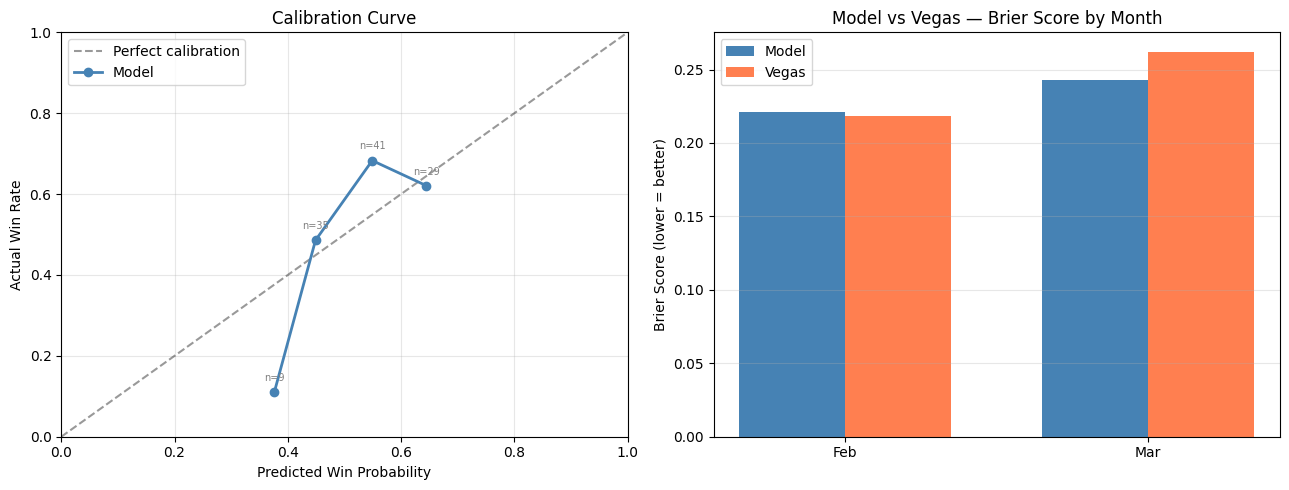

,date,home,away,home_pred,away_pred,lam_home,lam_away,ot_prob,home_win,status,home_ml,away_ml,home_mkt_prob,away_mkt_prob
0,2026-02-01,CAR,LAK,0.6062,0.3938,3.632,2.929,0.1509,1,OT,-180.0,150.0,0.642857,0.400000
1,2026-02-01,TBL,BOS,0.5597,0.4403,3.087,2.717,0.1633,1,SO,-220.0,180.0,0.687500,0.357143
2,2026-02-01,ANA,VGK,0.6760,0.3240,4.377,3.110,0.1330,1,Regulation,-115.0,-105.0,0.534884,0.512195
3,2026-02-02,FLA,BUF,0.3514,0.6486,2.683,3.661,0.1479,0,Regulation,-115.0,-105.0,0.534884,0.512195
4,2026-02-02,PIT,OTT,0.6621,0.3379,4.540,3.349,0.1319,0,Regulation,100.0,-120.0,0.500000,0.545455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,2026-03-06,CHI,VAN,0.4544,0.5456,2.714,2.994,0.1653,0,Regulation,-160.0,135.0,0.615385,0.425532
113,2026-03-06,EDM,CAR,0.5467,0.4533,4.124,3.788,0.1424,0,Regulation,-105.0,-115.0,0.512195,0.534884
114,2026-03-06,ANA,MTL,0.5568,0.4432,3.640,3.258,0.1513,1,SO,-105.0,-115.0,0.512195,0.534884
115,2026-03-06,VGK,MIN,0.4279,0.5721,3.136,3.618,0.1518,0,Regulation,100.0,-120.0,0.500000,0.545455


In [26]:
# ============================================================
# PART 12: ROLLING BACKTEST
# ============================================================
# Simulates running the model in real-time through the season.
# Each week: train on all data available up to that point,
# predict that week's games, record outcome vs prediction.
#
# Note: goalie season stats use the full 2025-26 season
# (minor lookahead bias — acceptable for a first-pass eval).
# ============================================================

import io, contextlib, matplotlib.pyplot as plt

PLAYED_STATUSES = {'Regulation', 'OT', 'SO'}


def rolling_backtest(prior_df, current_df, goalie_df,
                     csv_path=SCHEDULE_CSV,
                     start_date='2025-11-01',
                     step_days=7):
    """
    Rolling weekly backtest over the current season.

    Parameters
    ----------
    start_date : str   Begin predictions after this date (model needs
                       enough games to be meaningful, ~30+ recommended).
    step_days  : int   Retrain interval in days (default: weekly).
    """
    sched = load_schedule(csv_path)

    played = sched[sched['Status'].isin(PLAYED_STATUSES)].copy()
    played['home_score']    = pd.to_numeric(played['home_score'],    errors='coerce')
    played['visitor_score'] = pd.to_numeric(played['visitor_score'], errors='coerce')
    played = played.dropna(subset=['home_score', 'visitor_score'])
    played['home_win'] = (played['home_score'] > played['visitor_score']).astype(int)

    if isinstance(start_date, str):
        start_date = pd.to_datetime(start_date).date()

    current_df = current_df.copy()
    current_df['gameDate'] = pd.to_datetime(current_df['gameDate']).dt.date

    # Build weekly cutoffs from start_date to last played game
    max_date = played['Date'].max()
    cutoffs, d = [], start_date
    while d <= max_date:
        cutoffs.append(d)
        d += pd.Timedelta(days=step_days)
    cutoffs.append(max_date + pd.Timedelta(days=1))  # sentinel end

    total_weeks = len(cutoffs) - 1
    print(f"Rolling backtest: {start_date} → {max_date}")
    print(f"Retraining every {step_days} days  ({total_weeks} windows)\n")

    all_results = []

    for i in range(total_weeks):
        week_start = cutoffs[i]
        week_end   = cutoffs[i + 1]

        train_curr = current_df[current_df['gameDate'] < week_start].copy()
        n_train    = len(train_curr['gameId'].unique())

        if n_train < 20:
            continue  # not enough data yet

        # Train silently
        with contextlib.redirect_stdout(io.StringIO()):
            m = NHLPoissonModel(prior_df, train_curr, goalie_df)

        week_games = played[
            (played['Date'] >= week_start) & (played['Date'] < week_end)
        ]

        for _, game in week_games.iterrows():
            home = game['home_abbr']
            away = game['visitor_abbr']
            if pd.isna(home) or pd.isna(away):
                continue

            hg = game.get('Home Goalie')    or None
            ag = game.get('Visitor Goalie') or None
            if hg == '': hg = None
            if ag == '': ag = None

            p = m.predict(home, away, home_goalie=hg, away_goalie=ag)

            home_ml  = game.get('Home ML')
            away_ml  = game.get('Away ML')

            all_results.append({
                'date':          game['Date'],
                'home':          home,
                'away':          away,
                'home_pred':     p['home_win_prob'],
                'away_pred':     p['away_win_prob'],
                'lam_home':      p['lam_home'],
                'lam_away':      p['lam_away'],
                'ot_prob':       p['ot_prob'],
                'home_win':      game['home_win'],
                'status':        game['Status'],
                'home_ml':       home_ml,
                'away_ml':       away_ml,
                'home_mkt_prob': _american_to_prob(home_ml),
                'away_mkt_prob': _american_to_prob(away_ml),
            })

        print(f"  Week {i+1:02d}  {week_start} → {week_end}  "
              f"| train: {n_train} games  | predict: {len(week_games)} games")

    df = pd.DataFrame(all_results)
    print(f"\n✅ Done — {len(df)} games evaluated\n")
    return df


def backtest_metrics(results_df):
    """Compute Brier score, log-loss, accuracy vs Vegas + calibration plot."""
    df = results_df.dropna(subset=['home_pred', 'home_win']).copy()

    y = df['home_win'].values
    p = np.clip(df['home_pred'].values, 1e-6, 1 - 1e-6)

    brier   = np.mean((p - y) ** 2)
    logloss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    acc     = np.mean((p >= 0.5) == y)

    # Vegas metrics
    odds_df = df.dropna(subset=['home_mkt_prob']).copy()
    has_odds = len(odds_df) > 0
    if has_odds:
        pv = np.clip(odds_df['home_mkt_prob'].values, 1e-6, 1 - 1e-6)
        yv = odds_df['home_win'].values
        v_brier   = np.mean((pv - yv) ** 2)
        v_logloss = -np.mean(yv * np.log(pv) + (1 - yv) * np.log(1 - pv))
        v_acc     = np.mean((pv >= 0.5) == yv)

    print("=" * 52)
    print("  BACKTEST RESULTS")
    print("=" * 52)
    print(f"  Games evaluated : {len(df)}")
    print(f"\n  {'Metric':<22} {'Model':>8} {'Vegas':>8}")
    print(f"  {'-'*38}")
    v_b_str = f"{v_brier:>8.4f}"   if has_odds else f"{'—':>8}"
    v_l_str = f"{v_logloss:>8.4f}" if has_odds else f"{'—':>8}"
    v_a_str = f"{v_acc:>8.1%}"     if has_odds else f"{'—':>8}"
    print(f"  {'Brier Score':<22} {brier:>8.4f} {v_b_str}")
    print(f"  {'Log-Loss':<22} {logloss:>8.4f} {v_l_str}")
    print(f"  {'Accuracy':<22} {acc:>8.1%} {v_a_str}")
    print(f"\n  Random baseline Brier ≈ 0.2500")
    print(f"  Lower Brier / Log-Loss = better calibration")

    # ── Plots ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # --- Calibration curve ---
    ax = axes[0]
    bins = np.arange(0, 1.05, 0.10)
    bkt_pred, bkt_act, bkt_n = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi)
        if mask.sum() >= 5:
            bkt_pred.append(p[mask].mean())
            bkt_act.append(y[mask].mean())
            bkt_n.append(mask.sum())

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
    ax.plot(bkt_pred, bkt_act, 'o-', color='steelblue', lw=2, label='Model')
    for xp, ya, n in zip(bkt_pred, bkt_act, bkt_n):
        ax.annotate(f'n={n}', (xp, ya), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7, color='gray')
    ax.set_xlabel('Predicted Win Probability')
    ax.set_ylabel('Actual Win Rate')
    ax.set_title('Calibration Curve')
    ax.legend()
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

    # --- Monthly Brier: Model vs Vegas ---
    ax2 = axes[1]
    if has_odds:
        df2 = odds_df.copy()
        df2['month_dt']  = pd.to_datetime(df2['date'])
        df2['month_num'] = df2['month_dt'].dt.month
        df2['month_lbl'] = df2['month_dt'].dt.strftime('%b')

        monthly_rows = []
        for (mnum, mlbl), g in df2.groupby(['month_num', 'month_lbl']):
            gp = np.clip(g['home_pred'].values,    1e-6, 1 - 1e-6)
            gv = np.clip(g['home_mkt_prob'].values, 1e-6, 1 - 1e-6)
            gy = g['home_win'].values
            monthly_rows.append({
                'month_num':   mnum,
                'month':       mlbl,
                'Model Brier': np.mean((gp - gy) ** 2),
                'Vegas Brier': np.mean((gv - gy) ** 2),
            })
        monthly = pd.DataFrame(monthly_rows).sort_values('month_num')

        x = np.arange(len(monthly))
        w = 0.35
        ax2.bar(x - w/2, monthly['Model Brier'], w, label='Model', color='steelblue')
        ax2.bar(x + w/2, monthly['Vegas Brier'], w, label='Vegas',  color='coral')
        ax2.set_xticks(x)
        ax2.set_xticklabels(monthly['month'])
        ax2.set_ylabel('Brier Score (lower = better)')
        ax2.set_title('Model vs Vegas — Brier Score by Month')
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
    else:
        ax2.text(0.5, 0.5, 'No market odds available', ha='center', va='center',
                 transform=ax2.transAxes, fontsize=12)
        ax2.set_title('Model vs Vegas — Brier Score by Month')

    plt.tight_layout()
    plt.show()
    return df


# ── Run ────────────────────────────────────────────────────
# For a quick test (~4 windows, ~10 min), use start_date='2026-02-01'
# For a full season backtest (18 windows), use start_date='2025-11-01'
print("⏳ Starting rolling backtest...\n")
backtest_results = rolling_backtest(prior_season, current_season, goalie_df,
                                    start_date='2026-02-01')
backtest_metrics(backtest_results)

In [ ]:
# ============================================================
# PART 13: DAILY EDGE FINDER
# ============================================================
# Fill in the games the night before or morning of.
# Teams are pulled from the CSV automatically — only fill in
# odds and goalies for games you want to analyse.
#
# Odds format : American moneyline (e.g. -150, +130)
# Puck line   : always ±1.5 in NHL — just enter the odds
# Totals      : enter ou_line (e.g. 5.5) + over/under odds
# Goalie/b2b  : optional — omit if unconfirmed
# ============================================================

GAME_DATE = '2026-03-08'   # ← update each day

GAME_ODDS = {
    # 'HOME vs AWAY': dict(
    #     home_ml=...,  away_ml=...,           # moneyline
    #     home_pl=...,  away_pl=...,           # puck line odds (home -1.5 / away +1.5)
    #     ou_line=...,  over=...,  under=...,  # totals
    #     home_goalie='...', away_goalie='...' # optional
    # )
    'BOS vs MTL': dict(home_ml=-180, away_ml=+150,
                       home_pl=-115, away_pl=-105,
                       ou_line=5.5,  over=-110, under=-110,
                       home_goalie='Jeremy Swayman', away_goalie='Samuel Montembeault'),
    'TOR vs OTT': dict(home_ml=-130, away_ml=+110,
                       home_pl=+105, away_pl=-125,
                       ou_line=6.0,  over=-115, under=+105,
                       home_goalie='Anthony Stolarz', away_goalie='Linus Ullmark'),
    'EDM vs CGY': dict(home_ml=-160, away_ml=+135,
                       ou_line=6.5,  over=-105, under=-115),  # no goalies yet
}

# ── Do not edit below this line ────────────────────────────

def edge_finder(game_date, game_odds, model, csv_path=SCHEDULE_CSV):
    if isinstance(game_date, str):
        game_date = pd.to_datetime(game_date).date()

    sched    = load_schedule(csv_path)
    prev_day = game_date - pd.Timedelta(days=1)

    b2b_teams = set(
        sched[sched['Date'] == prev_day]['home_abbr'].dropna().tolist() +
        sched[sched['Date'] == prev_day]['visitor_abbr'].dropna().tolist()
    )

    day_games = sched[sched['Date'] == game_date]
    if len(day_games) == 0:
        print(f"No games found in CSV for {game_date}")
        return {}

    ml_rows = []
    pl_rows = []
    tot_rows = []

    for _, game in day_games.iterrows():
        home = game['home_abbr']
        away = game['visitor_abbr']
        if pd.isna(home) or pd.isna(away):
            continue

        key  = f"{home} vs {away}"
        info = game_odds.get(key, {})

        hg     = info.get('home_goalie') or None
        ag     = info.get('away_goalie') or None
        h_b2b  = home in b2b_teams
        a_b2b  = away in b2b_teams
        ou     = info.get('ou_line')

        p = model.predict(home, away, home_goalie=hg, away_goalie=ag,
                          home_b2b=h_b2b, away_b2b=a_b2b, ou_line=ou)

        goalie_str = f"{hg or '—'} / {ag or '—'}"
        b2b_str    = f"{'H✓' if h_b2b else ''} {'A✓' if a_b2b else ''}".strip() or '—'

        def calc_edge(model_prob, ml):
            mkt = _american_to_prob(ml)
            return round(model_prob - mkt, 4) if mkt else None

        def fmt_edge(e):
            return f"{e:+.1%}" if e is not None else '—'

        # ── Moneyline ────────────────────────────────────
        home_ml, away_ml = info.get('home_ml'), info.get('away_ml')
        hml_mkt = _american_to_prob(home_ml)
        aml_mkt = _american_to_prob(away_ml)
        total_mkt = (hml_mkt or 0) + (aml_mkt or 0)
        home_fair = hml_mkt / total_mkt if total_mkt else None
        away_fair = aml_mkt / total_mkt if total_mkt else None
        home_ml_edge = round(p['home_win_prob'] - home_fair, 4) if home_fair else None
        away_ml_edge = round(p['away_win_prob'] - away_fair, 4) if away_fair else None
        best_ml_side = home if (home_ml_edge or -99) >= (away_ml_edge or -99) else away
        best_ml_edge = max(e for e in [home_ml_edge, away_ml_edge] if e is not None) if any(e is not None for e in [home_ml_edge, away_ml_edge]) else None

        ml_rows.append({
            'Matchup':      key,
            'Model H%':     f"{p['home_win_prob']:.1%}",
            'Model A%':     f"{p['away_win_prob']:.1%}",
            'Fair H%':      f"{home_fair:.1%}" if home_fair else '—',
            'Fair A%':      f"{away_fair:.1%}" if away_fair else '—',
            'Home ML':      home_ml if home_ml is not None else '—',
            'Away ML':      away_ml if away_ml is not None else '—',
            'xG':           f"{p['lam_home']:.2f}-{p['lam_away']:.2f}",
            'OT%':          f"{p['ot_prob']:.1%}",
            'Goalies':      goalie_str,
            'B2B':          b2b_str,
            'Best Side':    best_ml_side if best_ml_edge is not None else '—',
            'Edge':         best_ml_edge,
        })

        # ── Puck line ─────────────────────────────────────
        home_pl, away_pl = info.get('home_pl'), info.get('away_pl')
        hpl_mkt = _american_to_prob(home_pl)
        apl_mkt = _american_to_prob(away_pl)
        total_pl = (hpl_mkt or 0) + (apl_mkt or 0)
        home_pl_fair = hpl_mkt / total_pl if total_pl else None
        away_pl_fair = apl_mkt / total_pl if total_pl else None
        home_pl_edge = round(p['home_pl_prob'] - home_pl_fair, 4) if home_pl_fair else None
        away_pl_edge = round(p['away_pl_prob'] - away_pl_fair, 4) if away_pl_fair else None
        best_pl_side = f"{home} -1.5" if (home_pl_edge or -99) >= (away_pl_edge or -99) else f"{away} +1.5"
        best_pl_edge = max(e for e in [home_pl_edge, away_pl_edge] if e is not None) if any(e is not None for e in [home_pl_edge, away_pl_edge]) else None

        pl_rows.append({
            'Matchup':       key,
            'Model H -1.5%': f"{p['home_pl_prob']:.1%}",
            'Model A +1.5%': f"{p['away_pl_prob']:.1%}",
            'Fair H -1.5%':  f"{home_pl_fair:.1%}" if home_pl_fair else '—',
            'Fair A +1.5%':  f"{away_pl_fair:.1%}" if away_pl_fair else '—',
            'Home PL':       home_pl if home_pl is not None else '—',
            'Away PL':       away_pl if away_pl is not None else '—',
            'Goalies':       goalie_str,
            'B2B':           b2b_str,
            'Best Side':     best_pl_side if best_pl_edge is not None else '—',
            'Edge':          best_pl_edge,
        })

        # ── Totals ────────────────────────────────────────
        over_odds, under_odds = info.get('over'), info.get('under')
        if ou is not None and p.get('over_fair') is not None:
            over_mkt   = _american_to_prob(over_odds)
            under_mkt  = _american_to_prob(under_odds)
            tot_total  = (over_mkt or 0) + (under_mkt or 0)
            over_fair  = over_mkt  / tot_total if tot_total else None
            under_fair = under_mkt / tot_total if tot_total else None
            over_edge  = round(p['over_fair']  - over_fair,  4) if over_fair  else None
            under_edge = round(p['under_fair'] - under_fair, 4) if under_fair else None
            best_tot_side = 'Over' if (over_edge or -99) >= (under_edge or -99) else 'Under'
            best_tot_edge = max(e for e in [over_edge, under_edge] if e is not None) if any(e is not None for e in [over_edge, under_edge]) else None
        else:
            over_edge = under_edge = best_tot_edge = None
            best_tot_side = '—'

        tot_rows.append({
            'Matchup':      key,
            'xG Total':     f"{p['expected_total']:.2f}",
            'O/U Line':     ou if ou is not None else '—',
            'Model Over%':  f"{p.get('over_fair', 0):.1%}" if p.get('over_fair') else '—',
            'Model Under%': f"{p.get('under_fair', 0):.1%}" if p.get('under_fair') else '—',
            'Over Odds':    over_odds if over_odds is not None else '—',
            'Under Odds':   under_odds if under_odds is not None else '—',
            'Goalies':      goalie_str,
            'B2B':          b2b_str,
            'Best Side':    best_tot_side if best_tot_edge is not None else '—',
            'Edge':         best_tot_edge,
        })

    def finalise(rows):
        df = pd.DataFrame(rows)
        df = df.sort_values('Edge', ascending=False).reset_index(drop=True)
        df['Edge'] = df['Edge'].apply(lambda x: f"{x:+.1%}" if pd.notna(x) and x is not None else '—')
        return df

    ml_df  = finalise(ml_rows)
    pl_df  = finalise(pl_rows)
    tot_df = finalise(tot_rows)

    date_str = game_date.strftime('%B %d, %Y')
    sep = '=' * 70

    print(f"\n{sep}")
    print(f"  EDGE FINDER — {date_str}  ({len(ml_df)} games)")
    print(f"{sep}")

    print(f"\n── MONEYLINE ──────────────────────────────────────────────────────")
    display(ml_df)

    print(f"\n── PUCK LINE (±1.5) ───────────────────────────────────────────────")
    display(pl_df)

    print(f"\n── TOTALS ─────────────────────────────────────────────────────────")
    display(tot_df)

    return {'moneyline': ml_df, 'puckline': pl_df, 'totals': tot_df}


edge_results = edge_finder(GAME_DATE, GAME_ODDS, model)


  EDGE FINDER — March 08, 2026  (7 games)

── MONEYLINE ──────────────────────────────────────────────────────


,Matchup,Model H%,Model A%,Fair H%,Fair A%,Home ML,Away ML,xG,OT%,Goalies,B2B,Best Side,Edge
0,COL vs MIN,62.2%,37.8%,—,—,—,—,4.05-3.20,14.2%,— / —,—,—,—
1,PIT vs BOS,51.8%,48.2%,—,—,—,—,3.15-3.04,16.0%,— / —,H✓ A✓,—,—
2,BUF vs TBL,50.6%,49.4%,—,—,—,—,3.35-3.31,15.5%,— / —,H✓ A✓,—,—
3,DAL vs CHI,62.0%,38.0%,—,—,—,—,3.47-2.70,15.3%,— / —,—,—,—
4,NJD vs DET,48.0%,52.0%,—,—,—,—,3.00-3.13,16.1%,— / —,H✓,—,—
5,ANA vs STL,67.6%,32.4%,—,—,—,—,3.75-2.58,14.3%,— / —,—,—,—
6,VGK vs EDM,42.0%,58.0%,—,—,—,—,3.44-4.00,14.5%,— / —,—,—,—



── PUCK LINE (±1.5) ───────────────────────────────────────────────


,Matchup,Model H -1.5%,Model A +1.5%,Fair H -1.5%,Fair A +1.5%,Home PL,Away PL,Goalies,B2B,Best Side,Edge
0,COL vs MIN,40.0%,60.0%,—,—,—,—,— / —,—,—,—
1,PIT vs BOS,28.3%,71.7%,—,—,—,—,— / —,H✓ A✓,—,—
2,BUF vs TBL,28.1%,71.9%,—,—,—,—,— / —,H✓ A✓,—,—
3,DAL vs CHI,37.8%,62.2%,—,—,—,—,— / —,—,—,—
4,NJD vs DET,25.0%,75.0%,—,—,—,—,— / —,H✓,—,—
5,ANA vs STL,44.0%,56.0%,—,—,—,—,— / —,—,—,—
6,VGK vs EDM,22.1%,77.9%,—,—,—,—,— / —,—,—,—



── TOTALS ─────────────────────────────────────────────────────────


,Matchup,xG Total,O/U Line,Model Over%,Model Under%,Over Odds,Under Odds,Goalies,B2B,Best Side,Edge
0,COL vs MIN,7.25,—,—,—,—,—,— / —,—,—,—
1,PIT vs BOS,6.19,—,—,—,—,—,— / —,H✓ A✓,—,—
2,BUF vs TBL,6.65,—,—,—,—,—,— / —,H✓ A✓,—,—
3,DAL vs CHI,6.17,—,—,—,—,—,— / —,—,—,—
4,NJD vs DET,6.13,—,—,—,—,—,— / —,H✓,—,—
5,ANA vs STL,6.33,—,—,—,—,—,— / —,—,—,—
6,VGK vs EDM,7.45,—,—,—,—,—,— / —,—,—,—
